In [1]:
# [Cell 1] 기본 임포트 & 폴더 세팅
import os
import time
import glob
from pathlib import Path

import numpy as np
import gym                     # JSBSim 환경 등록용
import gym_jsbsim              # gym.register 호출

from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

# === 로그/모델 디렉터리 ===
curtime = time.strftime("%Y%m%d%H%M", time.localtime())
base_tag = "turn_heading_control_ddpg"

log_dir  = f"./logs/{base_tag}/{curtime}/"
tb_dir   = f"./tb_logs/{base_tag}/"
best_dir = f"./best_model_ddpg/{curtime}/"
ckpt_dir = f"./checkpoints_ddpg/{curtime}/"
rb_dir   = f"./replay_buffers_ddpg/{curtime}/"

os.makedirs(log_dir, exist_ok=True)
os.makedirs(os.path.join(log_dir, "eval"), exist_ok=True)
os.makedirs(best_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(rb_dir, exist_ok=True)

# 환경 ID (예: Heading 제어 태스크)
env_id = "JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0"

# 재현성
seed = 41

# numpy 버전 호환 (일부 환경에서 필요)
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# [Cell 2] VecEnv 생성 함수 & 벡터라이즈드 환경 준비
def make_env():
    env = gym.make(env_id)
    try:
        env.seed(seed)
    except Exception:
        # 최신 gym이면 아래처럼 시드 설정
        try:
            env.reset(seed=seed)
            env.action_space.seed(seed)
            env.observation_space.seed(seed)
        except Exception:
            pass
    return env

train_vec = DummyVecEnv([make_env])
train_vec.seed(seed)
train_vec = VecMonitor(train_vec, log_dir)

eval_vec = DummyVecEnv([make_env])
eval_vec.seed(seed + 1)
eval_vec = VecMonitor(eval_vec, os.path.join(log_dir, "eval"))


/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym_jsbsim/environment.py:162: UserWarning: WARN: Could not seed environment <NoFGJsbSimEnv<JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0>>
  gym.logger.warn("Could not seed environment %s", self)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [3]:
# [Cell 3] 모델 준비 (DDPG) + 커스텀 로거 설정 (CSV + TensorBoard)
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.logger import configure

# 연속 행동 차원
n_actions = train_vec.action_space.shape[-1]

# 가우시안 액션 노이즈
action_noise = NormalActionNoise(mean=np.zeros(n_actions),
                                 sigma=0.2 * np.ones(n_actions))

# 새 모델을 만들거나 체크포인트에서 이어하기를 위한 헬퍼
def build_fresh_model():
    model = DDPG(
        policy="MlpPolicy",
        env=train_vec,
        learning_rate=1e-3,
        buffer_size=200_000,
        learning_starts=10_000,
        batch_size=256,
        tau=0.005,
        gamma=0.9,
        train_freq=(1, "episode"),
        gradient_steps=-1,
        action_noise=action_noise,
        tensorboard_log=tb_dir,
        verbose=1,
        seed=seed,
        device="auto",
    )
    # CSV + TensorBoard 로깅 활성화 (progress.csv 생성)
    logger = configure(log_dir, ["stdout", "csv", "tensorboard"])
    model.set_logger(logger)
    return model


In [4]:
# [Cell 4] 최신 체크포인트 & 리플레이 버퍼 자동 탐색/로드 함수
def latest_file_by_step(folder: str, prefix: str, suffix: str):
    """
    prefix_step_suffix 형태 파일 중 step이 가장 큰 파일 반환.
    예: ddpg_ckpt_50000_steps.zip, replay_buffer_50000_steps.pkl
    """
    files = glob.glob(str(Path(folder) / f"{prefix}*{suffix}"))
    best = None
    best_step = -1
    for f in files:
        name = Path(f).stem
        # 숫자 추출 (마지막 '_'와 'steps' 사이)
        try:
            step_str = name.split("_")[-2] if name.endswith("steps") else name.split("_")[-1]
            # 일반적으로 ..._{step}_steps.{ext}
            if step_str.isdigit():
                step = int(step_str)
            else:
                # ..._{step}_steps 패턴
                parts = name.split("_")
                step = int(parts[-2]) if parts[-1] == "steps" else -1
        except Exception:
            step = -1
        if step > best_step:
            best_step = step
            best = f
    return best, best_step

def try_resume_model():
    # 체크포인트(zip)와 리플레이 버퍼(pkl) 중 가장 최근 파일을 찾음
    ckpt, ckpt_step = latest_file_by_step(ckpt_dir, "ddpg_ckpt_", ".zip")
    if ckpt is None:
        return None, -1
    print(f"[Resume] Latest checkpoint: {ckpt}")

    # 환경 연결해서 로드
    model = DDPG.load(ckpt, env=train_vec, device="auto", print_system_info=False)
    # 로거 재설정 (진행 이어서 CSV/TB에 기록)
    logger = configure(log_dir, ["stdout", "csv", "tensorboard"])
    model.set_logger(logger)

    # 일치하는 step의 리플레이 버퍼가 있으면 로드
    rb_file = Path(rb_dir) / f"replay_buffer_{ckpt_step}_steps.pkl"
    if rb_file.exists():
        try:
            model.load_replay_buffer(str(rb_file))
            print(f"[Resume] Loaded replay buffer: {rb_file}")
        except Exception as e:
            print(f"[Resume] Replay buffer load failed ({e}), continue without it.")
    else:
        # 혹시 최신 버퍼가 step 미스매치인 경우 가장 최신 버퍼라도 불러본다
        rb_latest, rb_step = latest_file_by_step(rb_dir, "replay_buffer_", ".pkl")
        if rb_latest:
            try:
                model.load_replay_buffer(rb_latest)
                print(f"[Resume] Loaded latest replay buffer (step={rb_step}): {rb_latest}")
            except Exception as e:
                print(f"[Resume] Latest replay buffer load failed ({e}), continue without it.")
    return model, ckpt_step

# 모델 생성 또는 재개
model, resumed_step = try_resume_model()
if model is None:
    print("[Init] No checkpoint found. Build a fresh model.")
    model = build_fresh_model()
else:
    print(f"[Init] Resumed from step ~{resumed_step}.")


[Init] No checkpoint found. Build a fresh model.
Using cpu device
Logging to ./logs/turn_heading_control_ddpg/202508092355/


In [5]:
# [Cell 5] 콜백: 평가 + 체크포인트 + 리플레이 버퍼 주기 저장
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback

# 평가지표 콜백
eval_callback = EvalCallback(
    eval_env=eval_vec,
    best_model_save_path=best_dir,
    log_path=os.path.join(log_dir, "eval"),
    eval_freq=10_000,
    n_eval_episodes=10,
    deterministic=True,
    render=False,
)

# 모델 체크포인트 콜백 (주기적으로 zip 저장)
ckpt_callback = CheckpointCallback(
    save_freq=50_000,
    save_path=ckpt_dir,
    name_prefix="ddpg_ckpt",
    save_replay_buffer=False,   # 리플레이 버퍼는 아래 커스텀 콜백에서
    verbose=1,
)

# 리플레이 버퍼 저장 콜백
class ReplayBufferSaveCallback(BaseCallback):
    def __init__(self, save_freq: int, save_dir: str, verbose=0):
        super().__init__(verbose)
        self.save_freq = save_freq
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

    def _on_step(self) -> bool:
        if self.num_timesteps % self.save_freq == 0:
            path = os.path.join(self.save_dir, f"replay_buffer_{self.num_timesteps}_steps.pkl")
            try:
                self.model.save_replay_buffer(path)
                if self.verbose:
                    print(f"[RB] Saved replay buffer @ {self.num_timesteps} -> {path}")
            except Exception as e:
                if self.verbose:
                    print(f"[RB] Save failed: {e}")
        return True

rb_callback = ReplayBufferSaveCallback(save_freq=50_000, save_dir=rb_dir, verbose=1)

# 콜백 리스트
callbacks = [eval_callback, ckpt_callback, rb_callback]


In [6]:
# [Cell 6] 학습 시작 (중간에 끊겨도 체크포인트/버퍼 저장됨)
total_timesteps = 20000

try:
    model.learn(
        total_timesteps=total_timesteps,
        callback=callbacks,
        progress_bar=True,
        tb_log_name=f"{base_tag}_{curtime}",  # TensorBoard run name
    )
except KeyboardInterrupt:
    # 사용자가 중단 시 즉시 스냅샷 저장
    interrupt_model_path = os.path.join(ckpt_dir, f"ddpg_ckpt_{model.num_timesteps}_steps.zip")
    model.save(interrupt_model_path)
    try:
        model.save_replay_buffer(os.path.join(rb_dir, f"replay_buffer_{model.num_timesteps}_steps.pkl"))
    except Exception:
        pass
    print(f"\n[Interrupted] Saved snapshot to: {interrupt_model_path}")
except Exception as e:
    # 예기치 않은 에러에도 스냅샷
    crash_model_path = os.path.join(ckpt_dir, f"ddpg_crash_{model.num_timesteps}_steps.zip")
    model.save(crash_model_path)
    try:
        model.save_replay_buffer(os.path.join(rb_dir, f"replay_buffer_{model.num_timesteps}_steps.pkl"))
    except Exception:
        pass
    print(f"\n[Crash] {e}\nSaved crash snapshot to: {crash_model_path}")


/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: 
WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to 
rewrite the environment with new step API. 
  logger.deprecation(

/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym_jsbsim/environment.py:162: UserWarning: WARN: Could not seed environment <NoFGJsbSimEnv<JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0>>
  gym.logger.warn("Could not seed environment %s", self)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a 



     JSBSim Flight Dynamics Model v1.1.1 [GitHub build 134/commit c11b0ac53846798bca8f60132ebf8df935e1a802] Jul 31 2025 13:38:21
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 159      |
|    ep_rew_mean     | 39.9     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 1805     |
|    time_elapsed    | 0        |
|    total_timesteps | 636      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 155      |
|    ep_rew_mean     | 44.2     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 2296     |
|    time_elapsed    | 0        |
|    total_timesteps | 1243     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 140      |
|    ep_rew_mean     | 39  

Eval num_timesteps=10000, episode_reward=16.37 +/- 4.34

...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 115      |
|    ep_rew_mean     | 32.9     |
| time/              |          |
|    episodes        | 88       |
|    fps             | 1608     |
|    time_elapsed    | 6        |
|    total_timesteps | 10126    |
| train/             |          |
|    actor_loss      | 20.3     |
|    critic_loss     | 1.3      |
|    learning_rate   | 0.001    |
|    n_updates       | 210      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 113      |
|    ep_rew_mean     | 32.3     |
| time/              |          |
|    episodes        | 92       |
|    fps             | 1149     |
|    time_elapsed    | 9        |
|    total_timesteps | 10374    |
| train/             |          |
|    actor_loss      | 17.4     |
|    critic_loss     | 0.452    |
|    learning_rate   | 0.001    |
|    n_updates       | 457      |
--------------

Eval num_timesteps=20000, episode_reward=17.82 +/- 2.26

Episode length: 61.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 61       |
|    mean_reward     | 17.8     |
| time/              |          |
|    total_timesteps | 20000    |
| train/             |          |
|    actor_loss      | -21      |
|    critic_loss     | 0.165    |
|    learning_rate   | 0.001    |
|    n_updates       | 10123    |
---------------------------------


New best mean reward!

In [7]:
# [Cell 7] 최종 모델 저장 (베스트 모델은 EvalCallback이 따로 저장)
final_model_path = os.path.join(best_dir, "ddpg_final.zip")
model.save(final_model_path)
final_model_path


'./best_model_ddpg/202508092355/ddpg_final.zip'

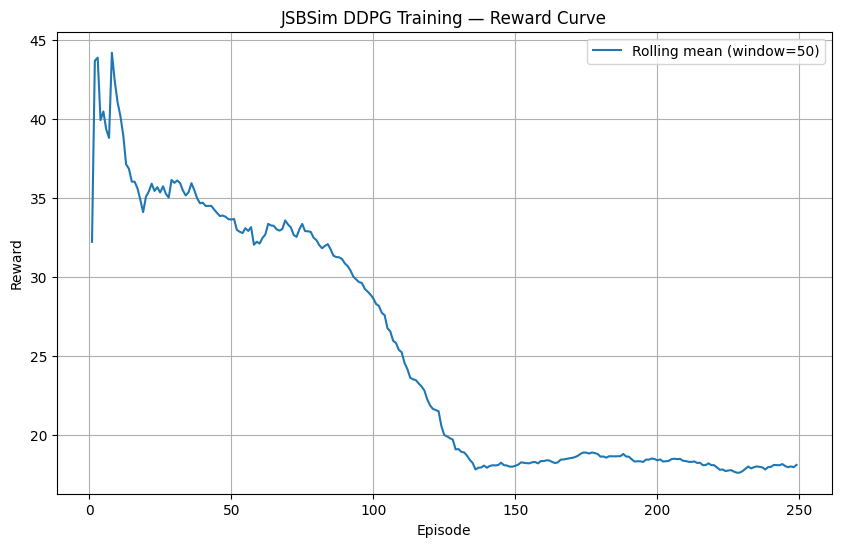

In [8]:
# [Cell 8] 보상 곡선(rolling mean) 시각화 - monitor.csv 기준
import pandas as pd
import matplotlib.pyplot as plt

# 학습 로그 CSV 수집 (eval/ 제외, 하위 폴더까지 검색)
files = glob.glob(str(Path(log_dir) / "monitor*.csv"))
if not files:
    files = glob.glob(str(Path(log_dir) / "**/monitor*.csv"), recursive=True)
files = [f for f in files if "eval" not in f]

if not files:
    raise FileNotFoundError(f"monitor*.csv not found under {log_dir}")

dfs = []
for f in sorted(files):
    df = pd.read_csv(f, comment="#")     # SB3 Monitor: columns r(리턴), l(길이), t(시간)
    dfs.append(df[["r", "l", "t"]])
data = pd.concat(dfs, ignore_index=True)
data["episode"] = range(1, len(data) + 1)

# 롤링 평균 보상
window = 50
data["rolling_reward"] = data["r"].rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(data["episode"], data["rolling_reward"], label=f"Rolling mean (window={window})")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("JSBSim DDPG Training — Reward Curve")
plt.grid(True)
plt.legend()
plt.show()


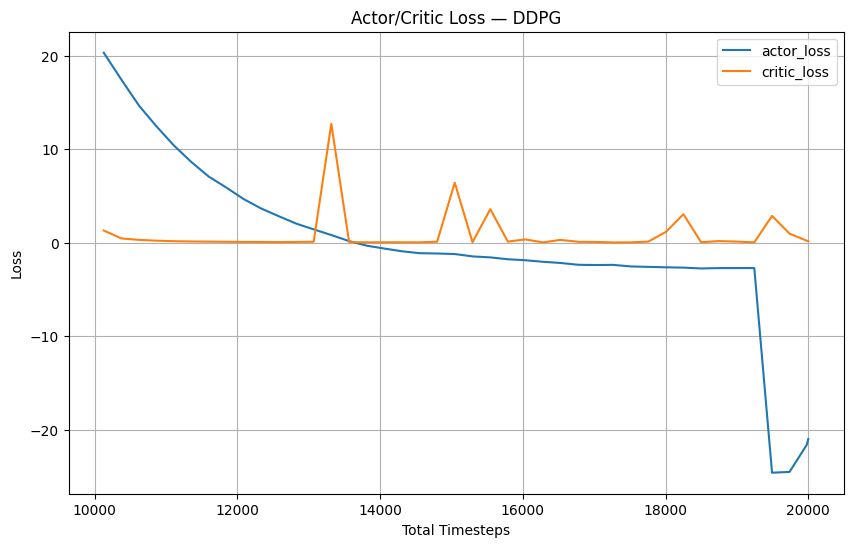

In [9]:
# [Cell 9] actor_loss / critic_loss 시각화 - progress.csv 기준
# Stable-Baselines3 로거에서 "train/actor_loss", "train/critic_loss"가 기록됩니다.
import pandas as pd
import matplotlib.pyplot as plt

progress_csv = Path(log_dir) / "progress.csv"
if not progress_csv.exists():
    # 혹시 다른 위치에 있을 수 있으니 재탐색
    cands = glob.glob(str(Path(log_dir) / "**/progress.csv"), recursive=True)
    if cands:
        progress_csv = Path(sorted(cands)[-1])
    else:
        raise FileNotFoundError(f"progress.csv not found under {log_dir}")

df = pd.read_csv(progress_csv)

# 컬럼 이름 안전 확인 (없을 경우 열 목록을 확인하세요)
actor_col = None
critic_col = None
for c in df.columns:
    if "train/actor_loss" in c:
        actor_col = c
    if "train/critic_loss" in c:
        critic_col = c

if actor_col is None or critic_col is None:
    print("[Warn] actor_loss/critic_loss columns not found in progress.csv.")
    print("Available columns:", list(df.columns)[:30])
else:
    # 스텝 기준 라인플롯
    x = df["time/total_timesteps"] if "time/total_timesteps" in df.columns else range(len(df))

    plt.figure(figsize=(10, 6))
    plt.plot(x, df[actor_col], label="actor_loss")
    plt.plot(x, df[critic_col], label="critic_loss")
    plt.xlabel("Total Timesteps")
    plt.ylabel("Loss")
    plt.title("Actor/Critic Loss — DDPG")
    plt.grid(True)
    plt.legend()
    plt.show()


In [11]:
# [Cell 10] 평가 (베스트 모델 or 최종 모델) + 단일 에피소드 롤아웃
from stable_baselines3.common.evaluation import evaluate_policy

# 콜백이 저장한 베스트 모델이 있으면 우선 사용
best_model_file = os.path.join(best_dir, "best_model.zip")
if os.path.exists(best_model_file):
    model_to_eval = DDPG.load(best_model_file, env=eval_vec)
else:
    # 방금 저장한 최종 모델 사용
    #final_model_path = os.path.join(best_dir, "ddpg_final.zip")
    best_model_path = os.path.join(best_dir, "best_model.zip")
    model_to_eval = DDPG.load(best_model_path, env=eval_vec)

mean_reward, std_reward = evaluate_policy(
    model_to_eval, 
    eval_vec, 
    n_eval_episodes=20, 
    deterministic=True, 
    render=False,
)
print(f"[DDPG] 평균 보상: {mean_reward:.2f} ± {std_reward:.2f}")

# 단일 에피소드 테스트 롤아웃
obs = eval_vec.reset()
done = [False]
episode_reward = 0.0

while not done[0]:
    action, _ = model_to_eval.predict(obs, deterministic=True)
    obs, reward, done, info = eval_vec.step(action)
    episode_reward += reward[0]

print(f"테스트 에피소드 보상: {episode_reward:.2f}")


/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym_jsbsim/environment.py:162: UserWarning: WARN: Could not seed environment <NoFGJsbSimEnv<JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0>>
  gym.logger.warn("Could not seed environment %s", self)


[DDPG] 평균 보상: 18.36 ± 2.87
테스트 에피소드 보상: 15.53


In [ ]:
# [Cell 11] (옵션) TensorBoard 사용 안내 (주석)
# 터미널에서 아래 명령 실행 후, 브라우저로 http://localhost:6006 접속:
# tensorboard --logdir ./tb_logs/turn_heading_control_ddpg/
#
# run name은 learn()에 지정한 tb_log_name (예: f"{base_tag}_{curtime}")로 표시됩니다.
